# CAPSTONE PROJECT

Submitted by Leslie Anne D. Dolot

## 📖 Outline
---

* Problem & Data Overview
* EDA Key Findings
* Feature Engineering Approach
* Model Selection & Methodology
* Results & Model Comparison
* Feature Importance & Explainability
* Limitations & Future Work

# 📑 Problem and Data Overview
---

Foodpanda’s review of August 2024–2025 data shows a high order cancellation rate (>30%), signaling issues across customers, riders, or restaurant partners. These cancellations lead to lost revenue (no commissions, delivery fees, or promo returns), increased operating costs (rider time/fuel, customer support, payment reversals), and poorer customer experience (delays, uncertainty, refunds). As a result, customers may switch to competitors, restaurants face wasted preparation and reduced trust, and riders experience lost income and lower morale—potentially affecting retention and service quality.

Additionally, frequent cancellations damage brand trust, reduce repeat usage, and distort demand forecasting, leading to poorer operational decisions.

Problem statement: “Which orders are likely to be cancelled before fulfillment?”

MAIN OBJECTIVE:

By being able to predict which orders are likely to be cancelled, we can reduce the number of order cancellations in a year and avoid or reduce the negative impacts of cancelled orders. Once the management is able to identify this, they could trigger proactive interventions (discounts, faster dispatch, alerts), provide changes, solutions and remedies before it results in a huge negative impact in the whole business financials.

SUCCESS METRICS:

Recall
F1 Score
Precision
ROC-AUC and PR-AUC

## Data Overview

In [1]:
import pandas as pd
file_name = 'Foodpanda Analysis Dataset.csv'
print('\n' + '='*80)
print('STEP 2: UPLOAD CSV FILE')
print('='*80)
df = pd.read_csv(file_name)
print(f'Loaded file: {file_name}')
print(f'Dataset shape: {df.shape}')
display(df.head())


STEP 2: UPLOAD CSV FILE
Loaded file: Foodpanda Analysis Dataset.csv
Dataset shape: (6000, 21)


,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,...,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status,Unnamed: 20
0,C5221,Male,Senior,Lahore,10/3/2023,O9221,1/10/2024,McDonald's,Burger,Italian,...,1291.14,Card,7,8/21/2025,42,Inactive,3,11/29/2024,Cancelled,NaN
1,C2831,Male,Adult,Multan,7/7/2024,O6831,8/23/2023,KFC,Burger,Italian,...,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed,NaN
2,C2851,Other,Senior,Multan,6/20/2025,O6851,8/23/2023,Pizza Hut,Fries,Italian,...,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed,NaN
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,8/23/2023,Subway,Pizza,Dessert,...,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed,NaN
4,C5641,Other,Senior,Islamabad,10/13/2023,O9641,3/27/2024,Pizza Hut,Burger,Chinese,...,620.96,Card,17,8/21/2025,206,Active,2,4/9/2025,Cancelled,NaN


## 📈 EDA Key Findings
---

* There are 32.32% cancelled orders in the past year from August 2024 to 2025.
* The order cost of cancellations ranges from 100 to 1500 Indian Rupees.
* The months of January, March, August, September and October have the highest cancellations (>500 counts)
* The top 3 most influential features for order cancellation are the week of the year, order quantity, and a certain city in India. 
 
## We lost 1,571,276.37 Indian Rupees which is equivalent to $ 16,623.60 due to order cancellations.

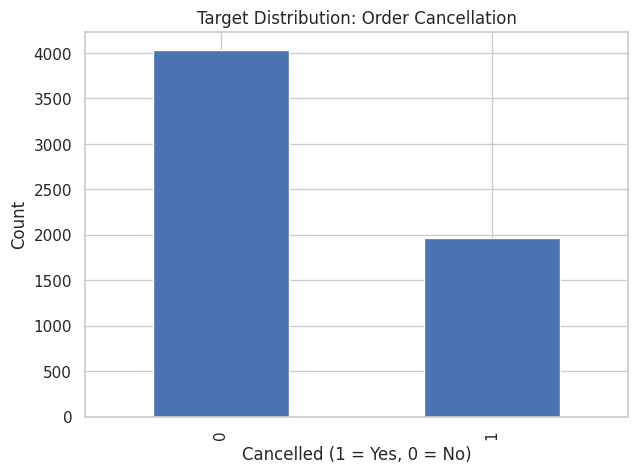

# ⚙️ FEATURE ENGINEERING APPROACH
---

* Dropping of identifiers such as customer id and order id
* Dropping of data leakages such as rating, rating date, and churned
* Review of potentially outlier variables
* Z-Score normalization of numerical data
* One-Hot-Encoding of categorical data
* Removal of data issues: some last order date occured after the order date
* Used delivery status (cancelled vs delivered) as the feature to compare with the other features

# 📊 MODEL SELECTION AND METHODOLOGY
---

I used Supervised Classification Algorithm for this scenario.
Three algorithms were tested and compared:

* Random Forest
* XGBoost
* SVM

Confusion Matrices were compared and analyzed during the process.
The resulting Recall, F1 Score, Precision, and ROC-AUC and PR-AUC were compared between the three algorithms to determine which is the most appropriate model to use.

# 📈 Results & Model Comparison
---
* Random Forest: High accuracy but failed to detect cancellations (1/984 detected)
* XGBoost: High precision, but still missed most cancellations (100/984 detected)
* SVM: Best at detecting cancellations (>50% recall), but with more false positives
* Trade-off: SVM enables intervention but may increase costs due to unnecessary actions

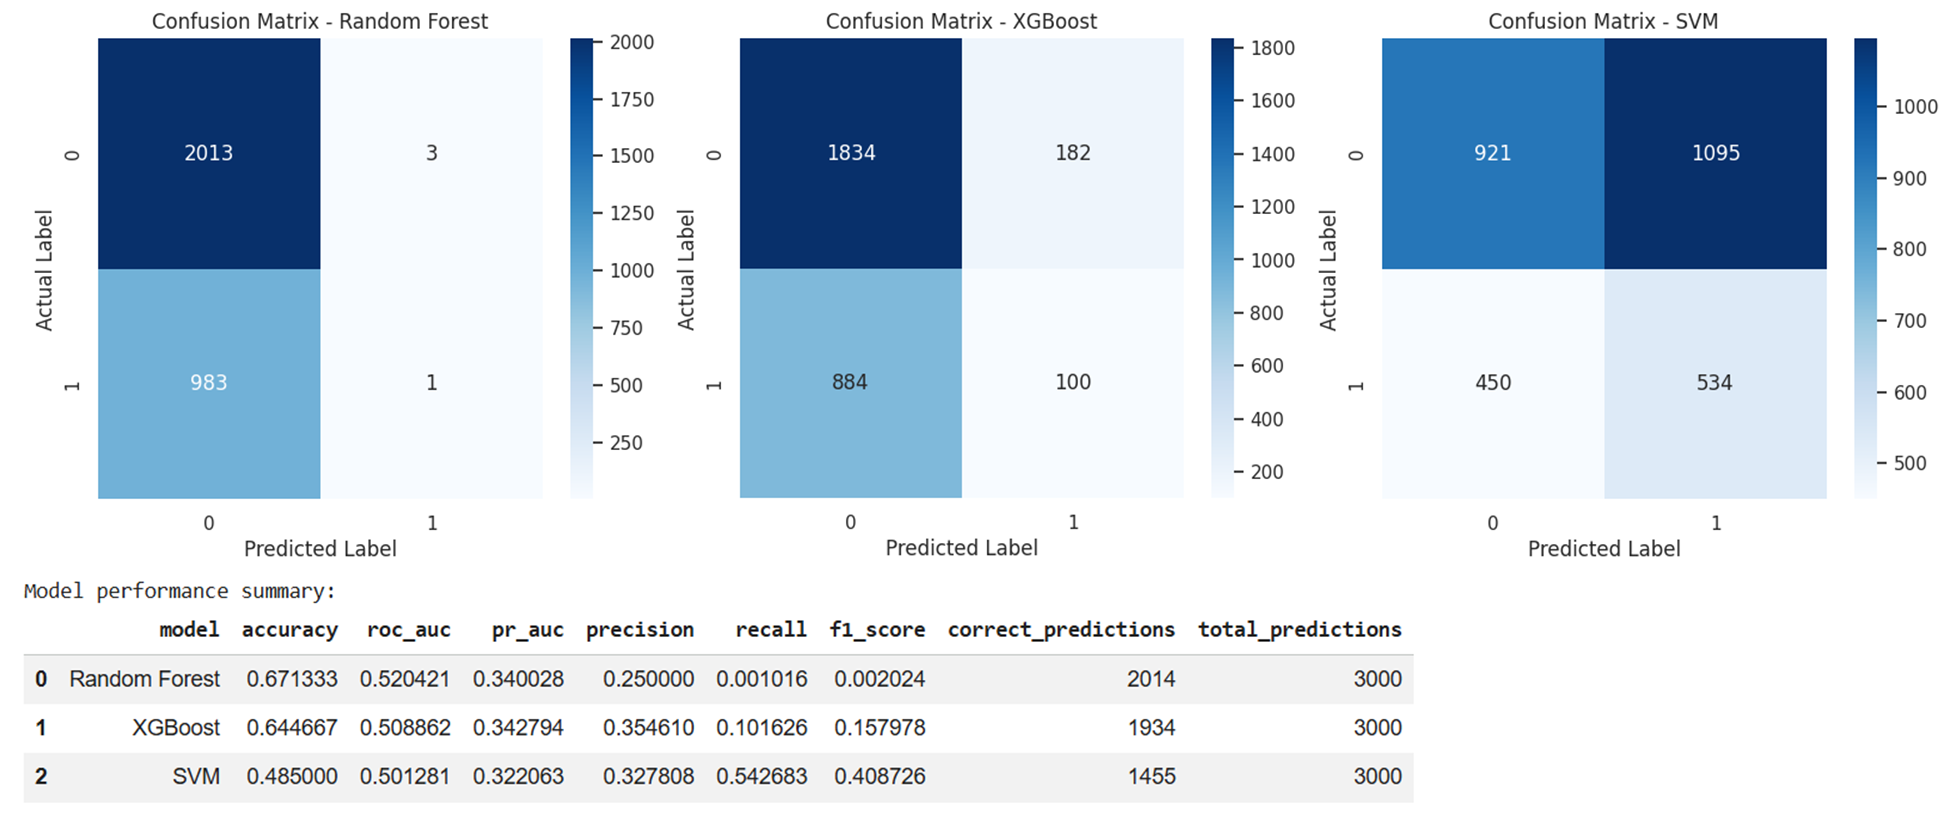

# 📌 FEATURE IMPORTANCE & EXPLAINABILITY
---
* The plot shows how each feature influences cancellation predictions
* Features are ranked by importance (top = most influential)
* Top drivers: order_weekofyear, quantity, city_Karachi
* X-axis (impact):
  * Right (+) → increases likelihood of cancellation (Class 1)
  * Left (–) → decreases likelihood (Class 0)
* Color meaning:
  * Red = higher feature values
  * More red points on the right → higher chance of cancellation

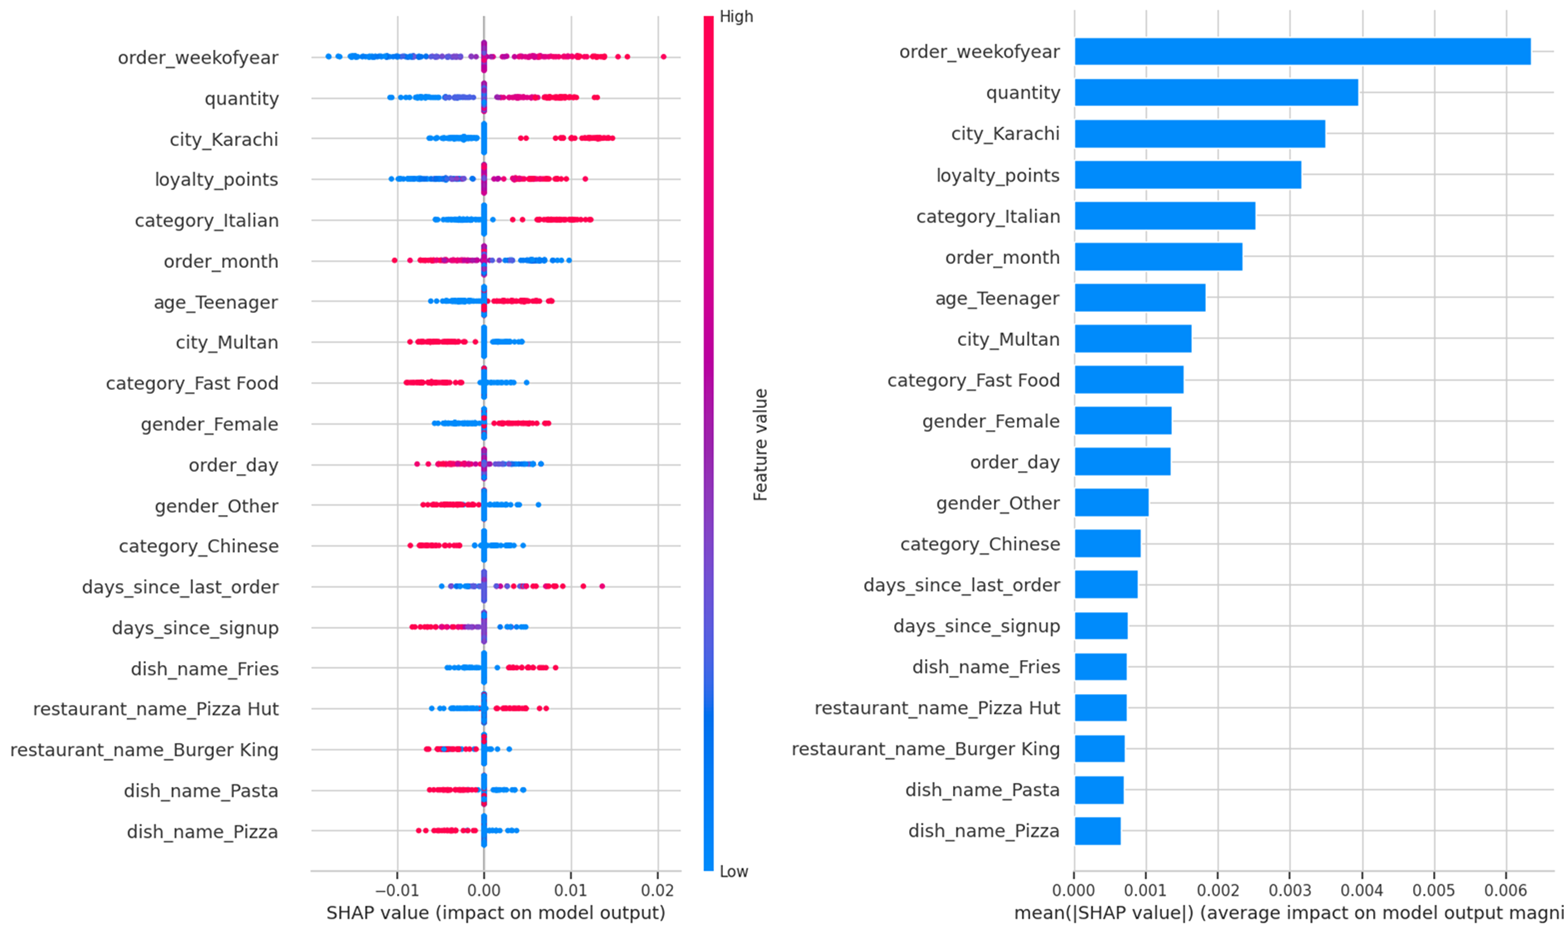

# LIMITATIONS & FUTURE WORK
---
* Results after use of fairness matrix such as demographic parity and equalized odds
    * there is significant disparity in predicted cancellation rates across different cities
    * there's a trend where the 'Other' group has the highest TPR and FPR, followed by 'Male' and then 'Female'.
* Biases: Proposed mitigations
  * Recommend to do reweighting for city and gender.

## Future Works

⚠️ Missing Key Variables

The dataset lacks important factors that influence order cancellations, such as:

* Delivery time (estimated vs. actual)
* Order-to-delivery/cancellation time
* Driver assignment time
* Restaurant preparation time
* Cancellation reasons and types
* External factors (weather, traffic, holidays)

➡️ Missing context likely explains the low model accuracy and weak feature/SHAP importance

📉 Data Coverage Limitation
Data spans Aug 2024 – Aug 2025, but patterns vary by month
Some months show higher/lower cancellations

➡️ A complete and consistent full-year dataset is needed to capture:

Seasonality (holidays, events)
External disruptions (traffic, roadworks, etc.)

✅ Recommendation
Enrich dataset with operational and external variables
Ensure full-year coverage to improve model performance and reliability


